# Análisis estadístico de `run_benchmark` (más allá de `launch_viz`)

Este notebook carga `results_metadata.parquet` y calcula estadísticas globales y por grupos diagnósticos:
- totales reales de `Wins`, `Regressions`, `High_Uncertainty`, `Edge_Cases` (sin muestreo),
- comparación con los IDs guardados en `focus_groups_ids.json` (muestreados),
- medias/medianas de `oks_base`, `oks_ours`, `delta_oks`, `entropy`, `nll`, `covariance_vol`,
- visualizaciones para entender el comportamiento del modelo.

In [33]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')

In [34]:
# Resolver raíz de proyecto
project_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
outputs_root = project_root / 'outputs'

# Busca runs con parquet
runs_with_parquet = []
for day in sorted(outputs_root.glob('*')):
    if not day.is_dir():
        continue
    for run in sorted(day.glob('*')):
        pq = run / 'results_metadata.parquet'
        if run.is_dir() and pq.exists():
            runs_with_parquet.append(run)

print(f'Runs con parquet encontrados: {len(runs_with_parquet)}')
for r in runs_with_parquet[-10:]:
    print('-', r.relative_to(project_root))

# Elige run automáticamente (el último con parquet) o asígnalo manualmente
if runs_with_parquet:
    run_dir = runs_with_parquet[-9]
else:
    # Ejemplo manual (ajústalo si no hay detección automática)
    run_dir = project_root / 'outputs' / '2026-02-13' / '16-53-57'

print('Run seleccionado:', run_dir.relative_to(project_root) if run_dir.exists() else run_dir)

Runs con parquet encontrados: 45
- outputs\2026-02-17\23-01-41
- outputs\2026-02-18\18-51-15
- outputs\2026-02-18\19-14-43
- outputs\comparisons\Baseline_Default
- outputs\comparisons\Photometric_Blur_3
- outputs\comparisons\Photometric_Brightness_10
- outputs\comparisons\Photometric_Brightness_30
- outputs\comparisons\Photometric_Contrast_0.8_1.2
- outputs\comparisons\Photometric_Noise_5
- outputs\comparisons\Photometric_None
Run seleccionado: outputs\2026-02-18\18-51-15


In [35]:
# Carga resultados masivos
parquet_path = run_dir / 'results_metadata.parquet'
assert parquet_path.exists(), f'No existe {parquet_path}'

df = pd.read_parquet(parquet_path)
print('Filas:', len(df))
print('Columnas:', list(df.columns))
df.head(3)

Filas: 2693
Columnas: ['image_id', 'dataset', 'oks_base', 'oks_ours', 'delta_oks', 'nll', 'entropy', 'covariance_vol', 'n_components', 'oks_base_nose', 'oks_ours_nose', 'delta_oks_nose', 'oks_base_left_eye', 'oks_ours_left_eye', 'delta_oks_left_eye', 'oks_base_right_eye', 'oks_ours_right_eye', 'delta_oks_right_eye', 'oks_base_left_ear', 'oks_ours_left_ear', 'delta_oks_left_ear', 'oks_base_right_ear', 'oks_ours_right_ear', 'delta_oks_right_ear', 'oks_base_left_shoulder', 'oks_ours_left_shoulder', 'delta_oks_left_shoulder', 'oks_base_right_shoulder', 'oks_ours_right_shoulder', 'delta_oks_right_shoulder', 'oks_base_left_elbow', 'oks_ours_left_elbow', 'delta_oks_left_elbow', 'oks_base_right_elbow', 'oks_ours_right_elbow', 'delta_oks_right_elbow', 'oks_base_left_wrist', 'oks_ours_left_wrist', 'delta_oks_left_wrist', 'oks_base_right_wrist', 'oks_ours_right_wrist', 'delta_oks_right_wrist', 'oks_base_left_hip', 'oks_ours_left_hip', 'delta_oks_left_hip', 'oks_base_right_hip', 'oks_ours_right_hi

,image_id,dataset,oks_base,oks_ours,delta_oks,nll,entropy,covariance_vol,n_components,oks_base_nose,...,delta_oks_left_knee,oks_base_right_knee,oks_ours_right_knee,delta_oks_right_knee,oks_base_left_ankle,oks_ours_left_ankle,delta_oks_left_ankle,oks_base_right_ankle,oks_ours_right_ankle,delta_oks_right_ankle
0,532481,coco,0.766623,0.742304,-0.024318,0.0,3.695997,2.358723,1,NaN,...,0.024686,0.805397,0.842586,0.037189,0.981188,0.997797,0.016608,0.865821,0.851909,-0.013912
1,458755,coco,0.686723,0.657188,-0.029535,0.0,3.435499,1.817792,1,NaN,...,0.000202,0.009250,0.013478,0.004228,NaN,NaN,NaN,0.070440,0.024469,-0.045971
2,385029,coco,0.935310,0.898180,-0.037130,0.0,4.624751,5.020576,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
# Definiciones diagnósticas (mismas reglas que diagnostics.py)
OKS_IMPROVEMENT_THRESHOLD = 0.1
OKS_FAILURE_THRESHOLD = 0.5
COV_VOL_QUANTILE = 0.90

wins_mask = df['oks_ours'] > (df['oks_base'] + OKS_IMPROVEMENT_THRESHOLD)
reg_mask = df['oks_base'] > (df['oks_ours'] + OKS_IMPROVEMENT_THRESHOLD)

if 'covariance_vol' in df.columns:
    cov_threshold = float(df['covariance_vol'].quantile(COV_VOL_QUANTILE))
    hu_mask = df['covariance_vol'] > cov_threshold
else:
    cov_threshold = np.nan
    hu_mask = pd.Series(False, index=df.index)

ec_mask = (df['oks_base'] < OKS_FAILURE_THRESHOLD) & (df['oks_ours'] < OKS_FAILURE_THRESHOLD)

totals = pd.DataFrame({
    'group': ['Wins', 'Regressions', 'High_Uncertainty', 'Edge_Cases'],
    'count_total_candidates': [int(wins_mask.sum()), int(reg_mask.sum()), int(hu_mask.sum()), int(ec_mask.sum())],
})

totals

,group,count_total_candidates
0,Wins,27
1,Regressions,28
2,High_Uncertainty,270
3,Edge_Cases,503


In [37]:
# Comparar contra focus_groups_ids.json (si existe, suele venir muestreado)
focus_path = run_dir / 'focus_groups_ids.json'
if focus_path.exists():
    with open(focus_path, 'r', encoding='utf-8') as f:
        focus = json.load(f)

    sampled = pd.DataFrame({
        'group': ['Wins', 'Regressions', 'High_Uncertainty', 'Edge_Cases'],
        'count_saved_in_focus_groups_ids': [
            len(focus.get('Wins', [])),
            len(focus.get('Regressions', [])),
            len(focus.get('High_Uncertainty', [])),
            len(focus.get('Edge_Cases', [])),
        ]
    })
    comparison = totals.merge(sampled, on='group', how='left')
else:
    comparison = totals.copy()
    comparison['count_saved_in_focus_groups_ids'] = np.nan

comparison

,group,count_total_candidates,count_saved_in_focus_groups_ids
0,Wins,27,27
1,Regressions,28,28
2,High_Uncertainty,270,50
3,Edge_Cases,503,50


In [38]:
# Estadísticas globales de métricas clave
metric_cols = [c for c in ['oks_base', 'oks_ours', 'delta_oks', 'nll', 'entropy', 'covariance_vol', 'n_components'] if c in df.columns]
stats = df[metric_cols].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
stats = stats.rename(columns={'50%': 'median'})
stats

,mean,std,min,25%,median,75%,max
oks_base,0.704167,0.328857,0.000000,0.676628,0.857495,0.919549,0.994082
oks_ours,0.705622,0.329354,0.000000,0.676003,0.857784,0.921547,0.996855
delta_oks,0.001455,0.042388,-0.641252,-0.008290,0.000000,0.012101,0.653961
nll,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
entropy,3.618875,0.798907,2.991918,3.134593,3.219755,3.767025,7.542503
covariance_vol,2.463434,3.916530,0.833795,1.328129,1.414443,1.788437,66.962593
n_components,1.053101,0.224276,1.000000,1.000000,1.000000,1.000000,2.000000


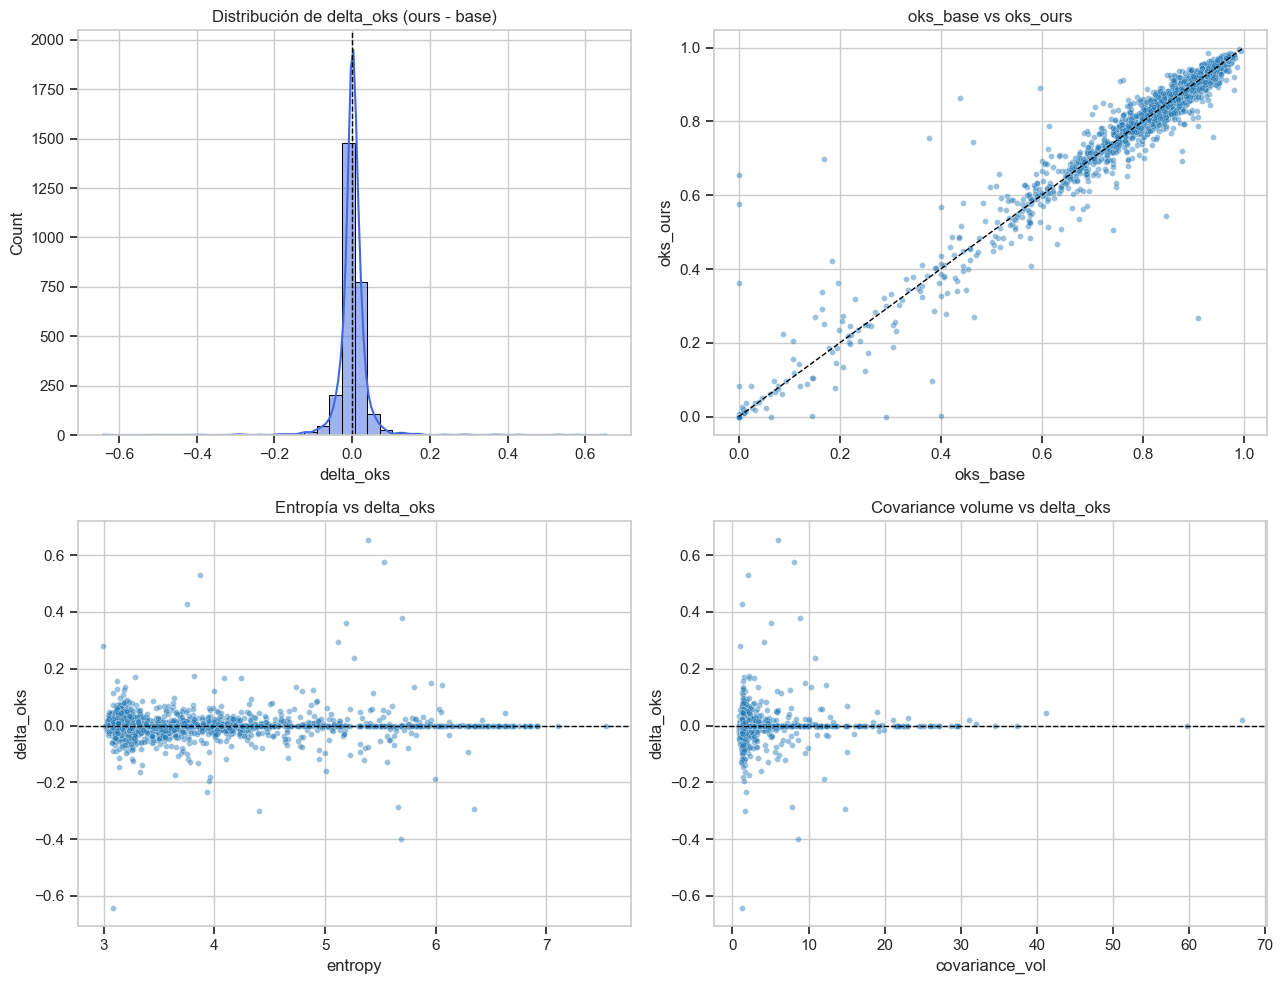

In [39]:
# Visualizaciones útiles para análisis
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 1) Histograma delta_oks
if 'delta_oks' in df.columns:
    sns.histplot(df['delta_oks'], bins=40, kde=True, ax=axes[0, 0], color='royalblue')
    axes[0, 0].axvline(0.0, color='black', linestyle='--', linewidth=1)
    axes[0, 0].set_title('Distribución de delta_oks (ours - base)')

# 2) Scatter oks_base vs oks_ours
if {'oks_base', 'oks_ours'}.issubset(df.columns):
    sns.scatterplot(data=df, x='oks_base', y='oks_ours', s=18, alpha=0.45, ax=axes[0, 1])
    lim_low = min(df['oks_base'].min(), df['oks_ours'].min())
    lim_high = max(df['oks_base'].max(), df['oks_ours'].max())
    axes[0, 1].plot([lim_low, lim_high], [lim_low, lim_high], 'k--', linewidth=1)
    axes[0, 1].set_title('oks_base vs oks_ours')

# 3) Entropía vs delta_oks
if {'entropy', 'delta_oks'}.issubset(df.columns):
    sns.scatterplot(data=df, x='entropy', y='delta_oks', s=18, alpha=0.45, ax=axes[1, 0])
    axes[1, 0].axhline(0.0, color='black', linestyle='--', linewidth=1)
    axes[1, 0].set_title('Entropía vs delta_oks')

# 4) Covariance volume vs delta_oks
if {'covariance_vol', 'delta_oks'}.issubset(df.columns):
    sns.scatterplot(data=df, x='covariance_vol', y='delta_oks', s=18, alpha=0.45, ax=axes[1, 1])
    axes[1, 1].axhline(0.0, color='black', linestyle='--', linewidth=1)
    axes[1, 1].set_title('Covariance volume vs delta_oks')

plt.tight_layout()
plt.show()

In [40]:
# Top casos para inspección manual
cols = [c for c in ['image_id', 'dataset', 'oks_base', 'oks_ours', 'delta_oks', 'entropy', 'nll', 'covariance_vol'] if c in df.columns]

print('Top 10 mejoras (delta_oks alto):')
display(df.sort_values('delta_oks', ascending=False)[cols].head(10))

print('Top 10 regresiones (delta_oks bajo):')
display(df.sort_values('delta_oks', ascending=True)[cols].head(10))

Top 10 mejoras (delta_oks alto):


,image_id,dataset,oks_base,oks_ours,delta_oks,entropy,nll,covariance_vol
2548,581206,coco,1.689214e-08,0.653961,0.653961,5.388917,0.0,5.981410
1690,447611,coco,7.360285e-09,0.577088,0.577088,5.532941,0.0,8.031893
1587,62353,coco,1.683275e-01,0.698088,0.529761,3.866286,0.0,2.023794
1596,267169,coco,4.372537e-01,0.864736,0.427482,3.747601,0.0,1.261440
2209,367195,coco,3.767244e-01,0.755623,0.378898,5.692485,0.0,8.862609
1409,151938,coco,1.067635e-40,0.361818,0.361818,5.192976,0.0,5.045618
376,484415,coco,5.962308e-01,0.889491,0.293260,5.113412,0.0,4.137342
1318,331817,coco,4.636579e-01,0.744045,0.280387,2.991918,0.0,1.047652
2462,302452,coco,1.842436e-01,0.421895,0.237652,5.264646,0.0,10.901384
122,532855,coco,1.646627e-01,0.338648,0.173985,3.815128,0.0,2.192914


Top 10 regresiones (delta_oks bajo):


,image_id,dataset,oks_base,oks_ours,delta_oks,entropy,nll,covariance_vol
584,403122,coco,0.908921,2.676690e-01,-0.641252,3.082455,0.0,1.277082
2231,121497,coco,0.400735,5.866689e-04,-0.400148,5.682698,0.0,8.595366
549,206411,coco,0.845726,5.450638e-01,-0.300662,4.405071,0.0,1.656764
1308,528399,coco,0.292516,3.089630e-23,-0.292516,6.346718,0.0,14.822719
2660,311190,coco,0.382497,9.744825e-02,-0.285048,5.662596,0.0,7.782205
1881,128654,coco,0.740443,5.048152e-01,-0.235628,3.930756,0.0,1.817272
2633,8021,coco,0.465937,2.697768e-01,-0.196160,3.951827,0.0,1.580780
2656,311180,coco,0.878528,6.914405e-01,-0.187087,5.990707,0.0,12.043003
2115,407868,coco,0.939151,7.586003e-01,-0.180551,3.959350,0.0,1.369168
1160,110042,coco,0.579712,4.071697e-01,-0.172542,3.639065,0.0,2.228187
